#### Business Question
PowerCo is losing customers. This customer attrition, or churn, is eating into margins and threatening long-term growth.Uuncover what’s driving this chur?.

#### Business Understanding and Problem Framing
- **Hypothesis** : The customer churn is driven by price sensitivity.Price sensitivity is the degree to which demand changes when the cost of a product or service changes.. 
- **Test_of_Hypothesis** : Test the hypothesis that churn is driven by customers' price sensitivity

#### Import Packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
# Shows plots in jupyter notebook
%matplotlib inline
# Set plot style
sns.set(color_codes=True)

### Data Collection and Data Understanding

In [3]:
client_df = pd.read_csv(r"C:\working_files\Company_client_data.csv")
price_df = pd.read_csv(r"C:\working_files\Company_Products_price_data.csv")

### Data Description
#### client_data
- id = client company identifier
- activity_new = category of the company’s activity
- channel_sales = code of the sales channel
- cons_12m = electricity consumption of the past 12 months
- cons_gas_12m = gas consumption of the past 12 months
- cons_last_month = electricity consumption of the last month
- date_activ = date of activation of the contract
- date_end = registered date of the end of the contract
- date_modif_prod = date of the last modification of the product
- date_renewal = date of the next contract renewal
- forecast_cons_12m = forecasted electricity consumption for next 12 months
- forecast_cons_year = forecasted electricity consumption for the next calendar year
- forecast_discount_energy = forecasted value of current discount
- forecast_meter_rent_12m = forecasted bill of meter rental for the next 2 months
- forecast_price_energy_off_peak = forecasted energy price for 1st period (off peak)
- forecast_price_energy_peak = forecasted energy price for 2nd period (peak)
- forecast_price_pow_off_peak = forecasted power price for 1st period (off peak)
- has_gas = indicated if client is also a gas client
- imp_cons = current paid consumption
- margin_gross_pow_ele = gross margin on power subscription
- margin_net_pow_ele = net margin on power subscription
- nb_prod_act = number of active products and services
- net_margin = total net margin
- num_years_antig = antiquity of the client (in number of years)
- origin_up = code of the electricity campaign the customer first subscribed to
- pow_max = subscribed power
- churn = has the client churned over the next 3 months
#### price_data
- id = client company identifier
- price_date = reference date
- price_off_peak_var = price of energy for the 1st period (off peak)
- price_peak_var = price of energy for the 2nd period (peak)
- price_mid_peak_var = price of energy for the 3rd period (mid peak)
- price_off_peak_fix = price of power for the 1st period (off peak)
- price_peak_fix = price of power for the 2nd period (peak)
- price_mid_peak_fix = price of power for the 3rd period (mid peak)


In [4]:
client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [5]:
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [6]:
client_df.columns

Index(['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'date_activ', 'date_end', 'date_modif_prod', 'date_renewal',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn'],
      dtype='object')

In [7]:
client_df.shape

(14606, 26)

we have 14606 instances and 26 attributes in the client_data

In [8]:
price_df.columns

Index(['id', 'price_date', 'price_off_peak_var', 'price_peak_var',
       'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix',
       'price_mid_peak_fix'],
      dtype='object')

In [9]:
price_df.shape

(193002, 8)

we have 193002 instances and 8 attributes in the Price_data

#### Descriptive Statistics of data

In [10]:
# Descriptive statistics for client_data
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [11]:
categorical_columns = client_df[["channel_sales","has_gas","origin_up"]]

In [12]:
for col in categorical_columns:
    print(client_df[col].value_counts())
 

channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64
has_gas
f    11955
t     2651
Name: count, dtype: int64
origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64


In [13]:
# Descriptive statistics for Price Data
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


#### statistical summary

In [14]:
# statistical summary of Client_data
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [15]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


#### Data Preprocessing

In [16]:
# Check missing values in Client Data
client_df.isnull().sum()

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64

In [17]:
# Check missing values in Price Data
price_df.isnull().sum()

id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64

In [18]:
# Check for duplictes
client_df.duplicated().sum()

0

In [19]:
# Check for duplictes
price_df.duplicated().sum()

0

### EDA

In [20]:
numerical_cols = client_df.select_dtypes(include=["number"])

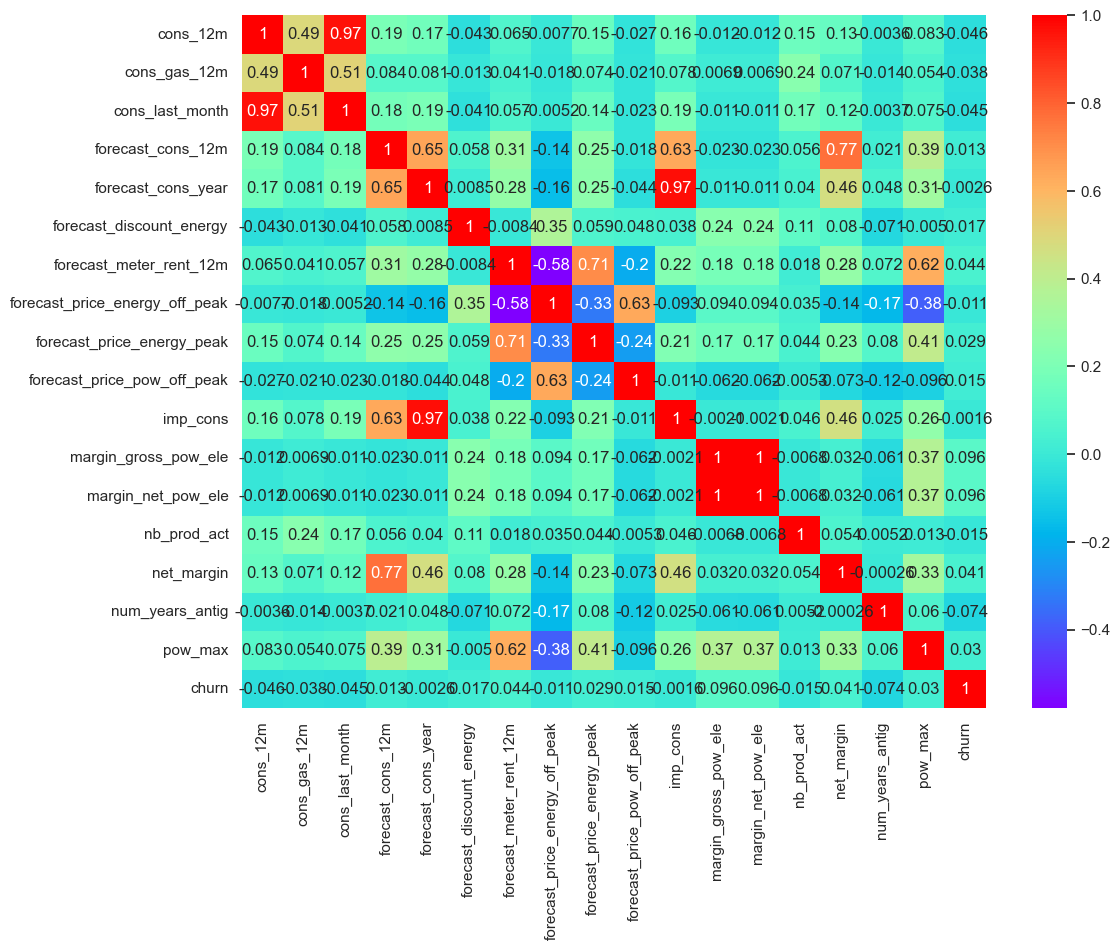

In [21]:
plt.figure(figsize=(12,9))
sns.heatmap(numerical_cols.corr(), annot = True, cmap='rainbow')
plt.show()

 #### Target Variable Analysis

In [22]:
# Explore the target variable
client_df.churn.value_counts()

churn
0    13187
1     1419
Name: count, dtype: int64

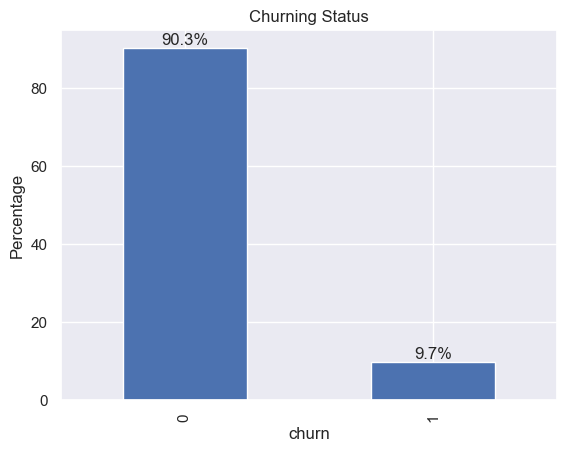

In [23]:
churn_pct = client_df['churn'].value_counts(normalize=True) * 100

ax = churn_pct.plot(kind='bar')

ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.title("Churning Status")
plt.ylabel("Percentage")
plt.show()

**Observation**:
Approximately 10% of the total customers has churned

In [24]:
client_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cons_12m,14606.0,159220.286252,573465.264198,0.0,5674.750000,14115.500000,40763.750000,6.207104e+06
cons_gas_12m,14606.0,28092.375325,162973.059057,0.0,0.000000,0.000000,0.000000,4.154590e+06
cons_last_month,14606.0,16090.269752,64364.196422,0.0,0.000000,792.500000,3383.000000,7.712030e+05
forecast_cons_12m,14606.0,1868.614880,2387.571531,0.0,494.995000,1112.875000,2401.790000,8.290283e+04
forecast_cons_year,14606.0,1399.762906,3247.786255,0.0,0.000000,314.000000,1745.750000,1.753750e+05
forecast_discount_energy,14606.0,0.966726,5.108289,0.0,0.000000,0.000000,0.000000,3.000000e+01
forecast_meter_rent_12m,14606.0,63.086871,66.165783,0.0,16.180000,18.795000,131.030000,5.993100e+02
forecast_price_energy_off_peak,14606.0,0.137283,0.024623,0.0,0.116340,0.143166,0.146348,2.739630e-01
forecast_price_energy_peak,14606.0,0.050491,0.049037,0.0,0.000000,0.084138,0.098837,1.959750e-01
forecast_price_pow_off_peak,14606.0,43.130056,4.485988,0.0,40.606701,44.311378,44.311378,5.926638e+01


#### Distribution of Numerical Variables

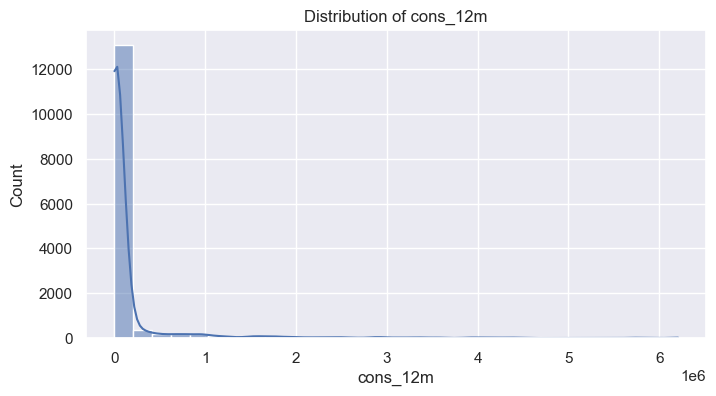

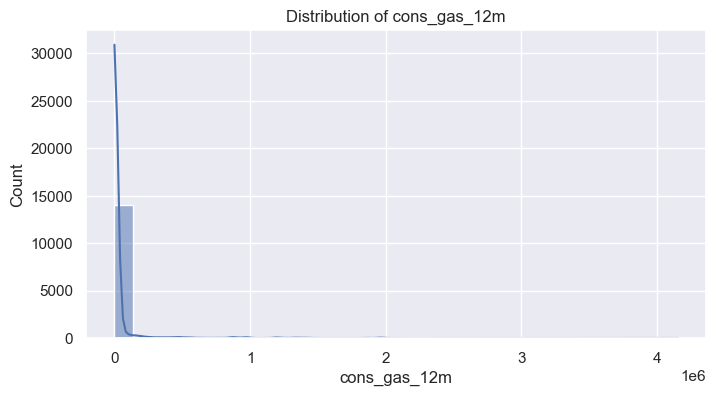

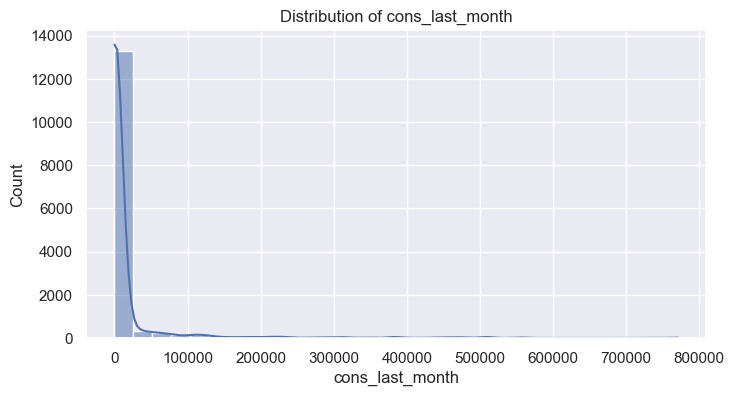

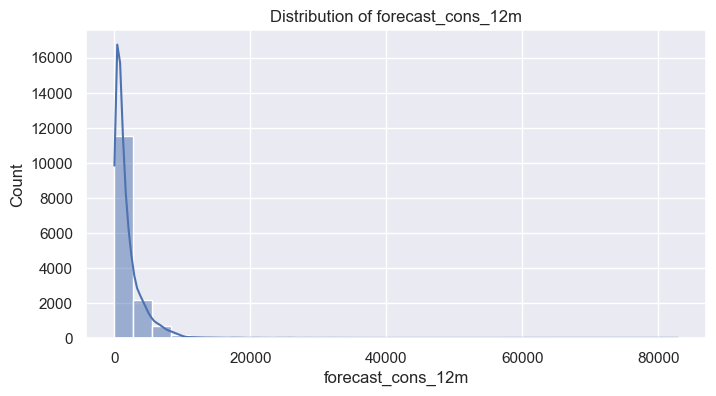

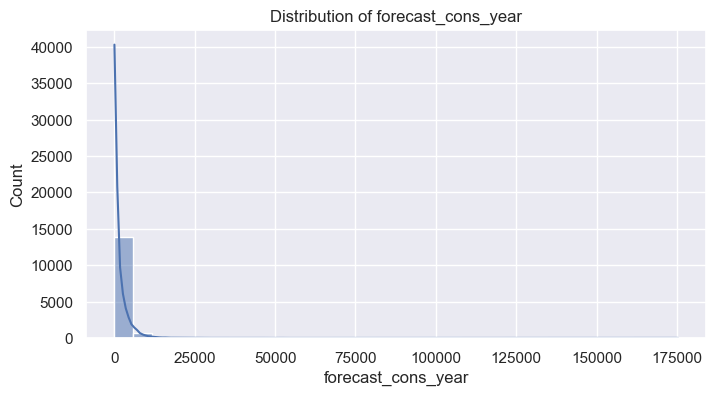

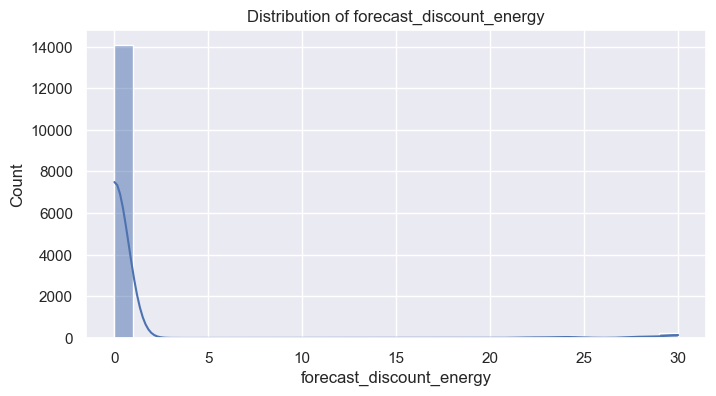

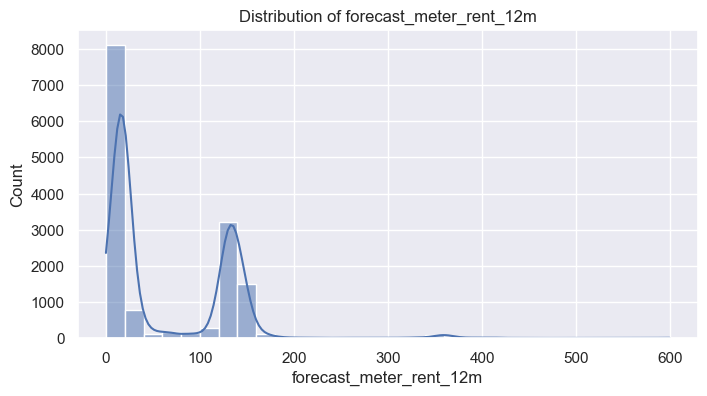

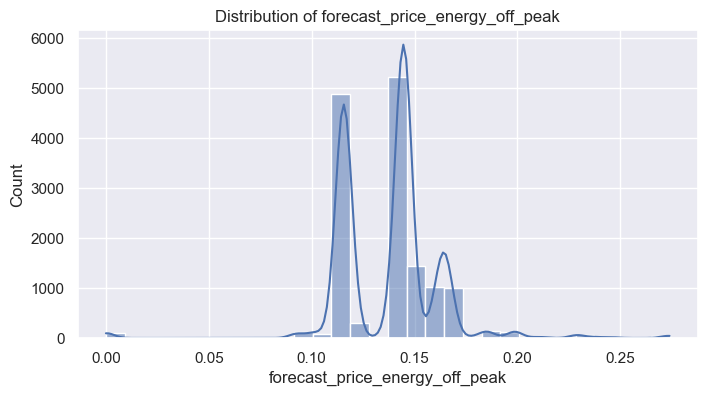

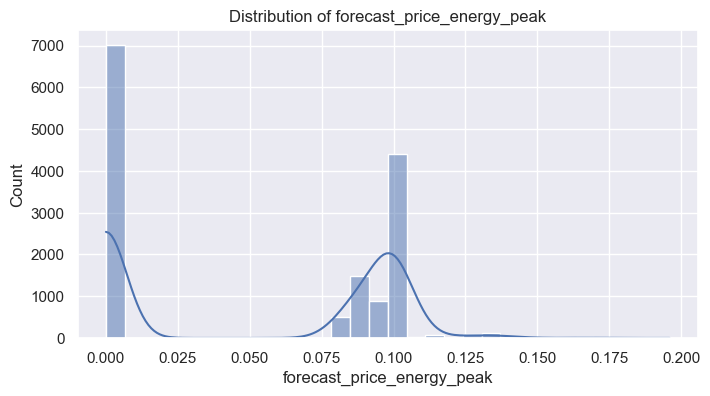

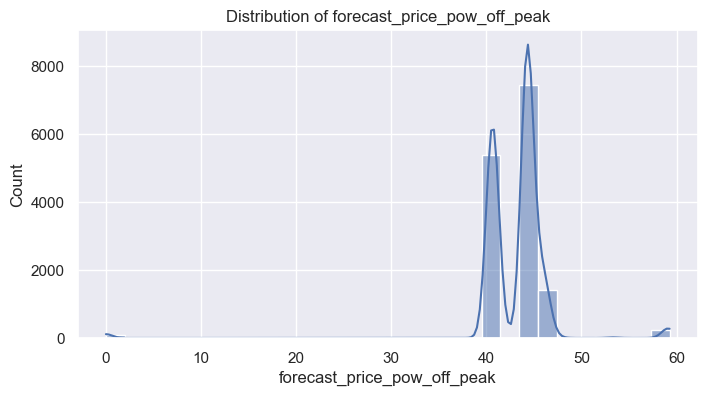

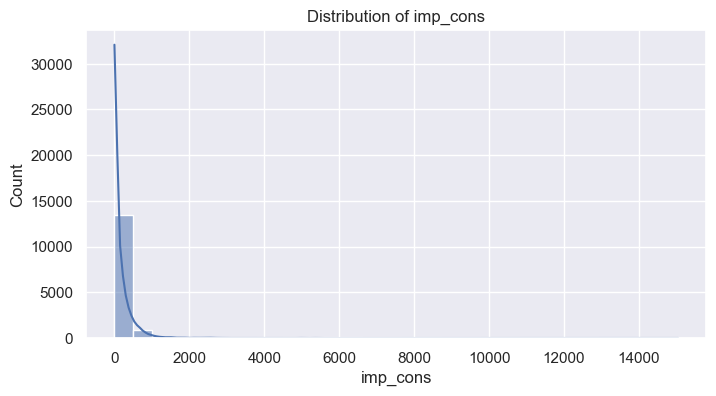

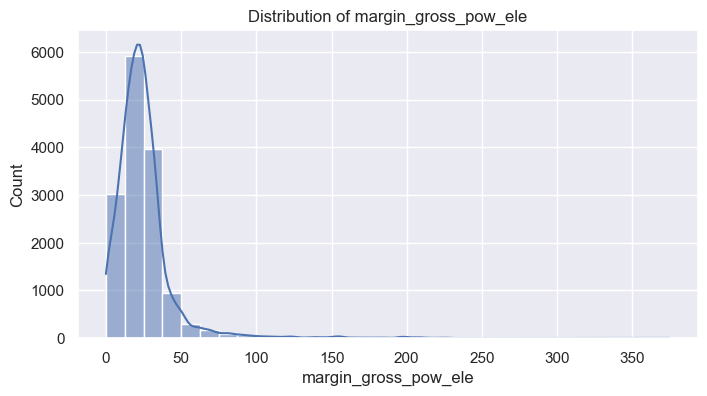

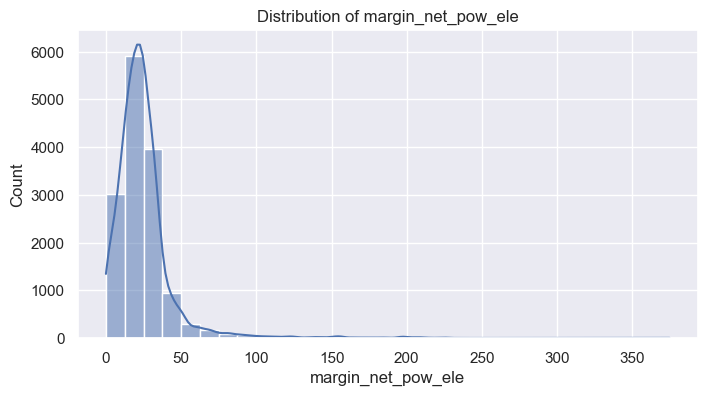

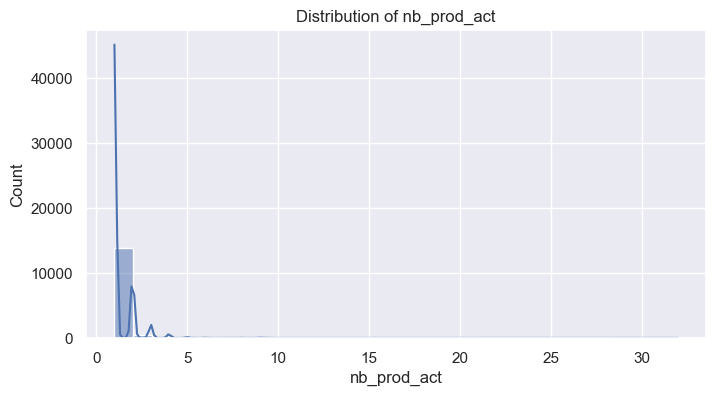

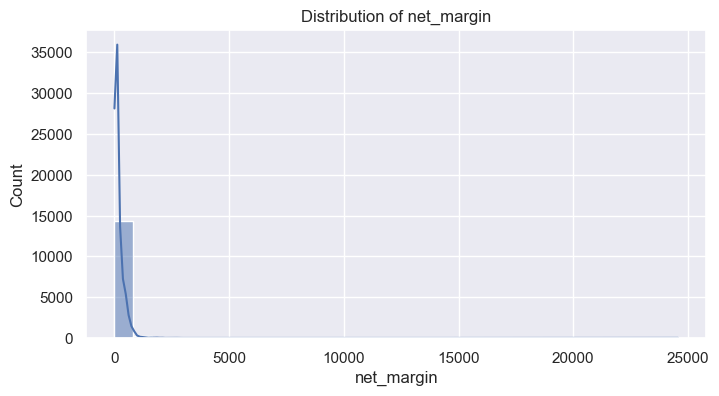

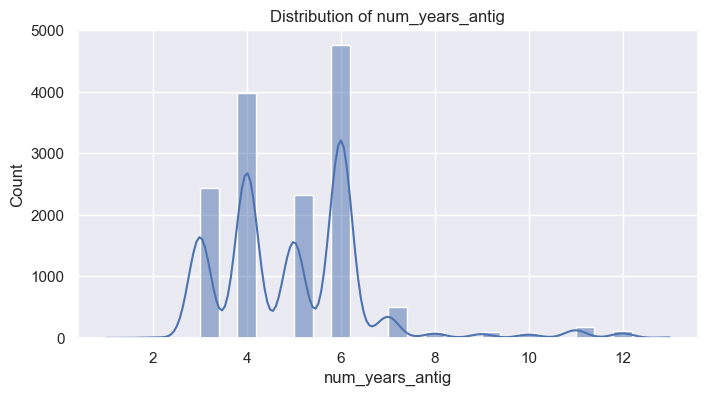

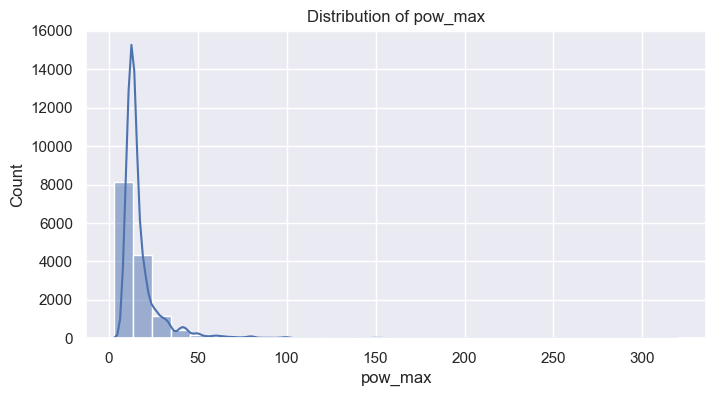

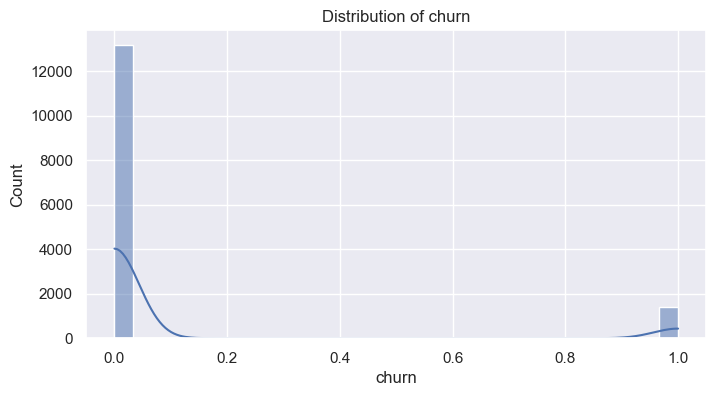

In [25]:
import numpy as np
numerical_cols = client_df.select_dtypes(include=np.number).columns

for col in numerical_cols:

    plt.figure(figsize=(8,4))
    sns.histplot(client_df[col],bins=30,kde=True)

    plt.title(f"Distribution of {col}")
    plt.show()

#### Observation
- Clearly, the consumption data('cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons) is highly positively skewed, presenting a very long right-tail towards the higher values of the distribution. The values on the higher and lower end of the distribution are likely to be outliers.
- Similarly to the consumption plots, we can observe that a lot of the variables are highly positively skewed, creating a very long tail for the higher values. We will make use of "Transformation Technique" to correct this skewness.

#### Check for Outliers

We can use a standard plot to visualise the outliers in more detail. A boxplot is a standardized way of displaying the distribution based on a five number summary.It can also tell us if our data is symmetrical, how tightly our data is grouped and if/how our data is skewed
- Minimum
- First quartile (Q1)
- Median
- Third quartile (Q3)
- Maximum


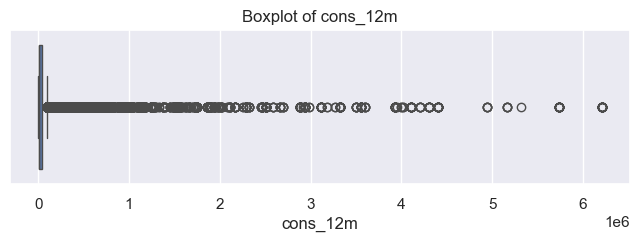

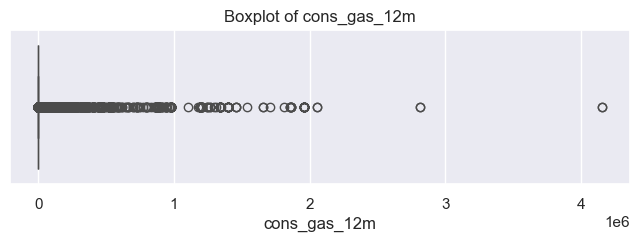

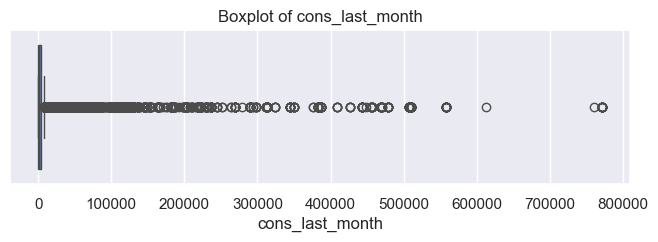

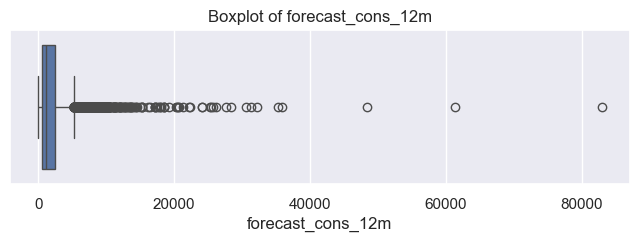

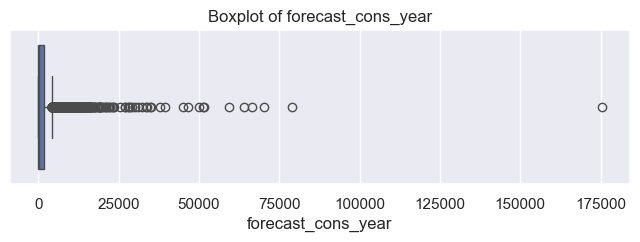

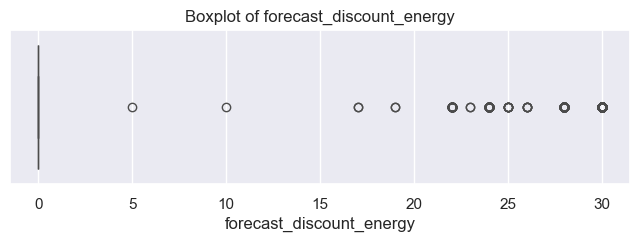

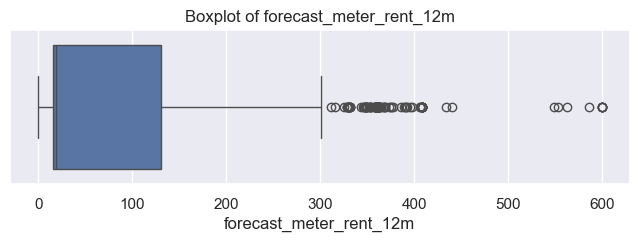

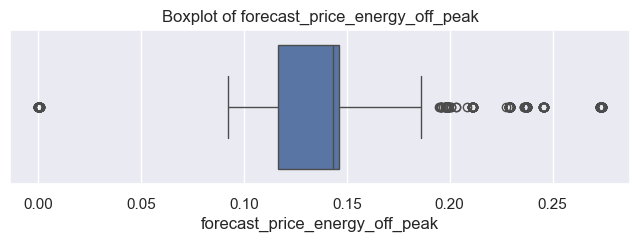

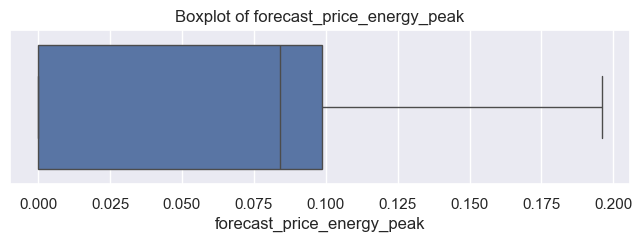

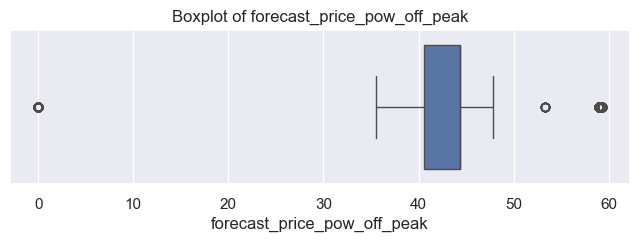

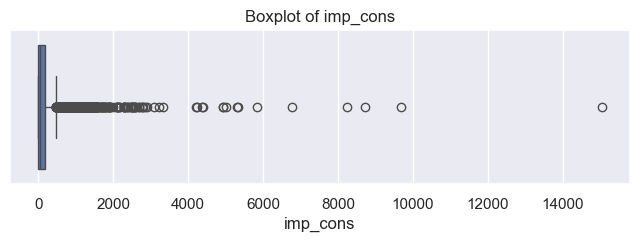

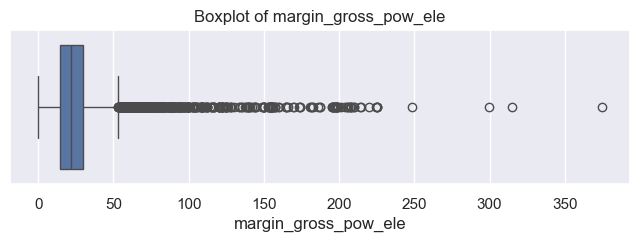

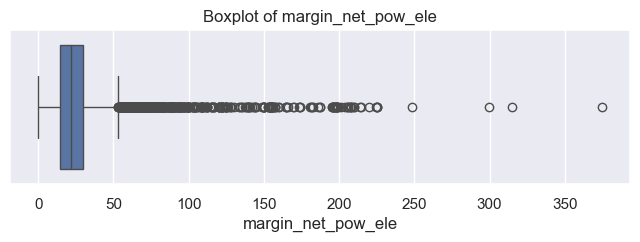

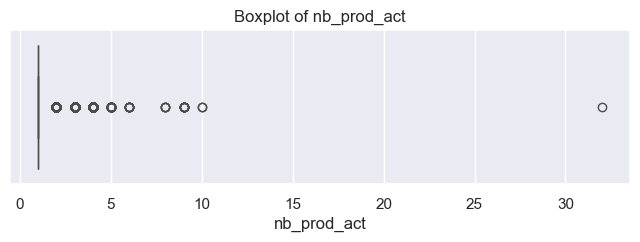

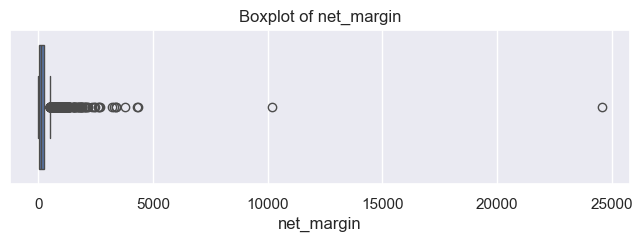

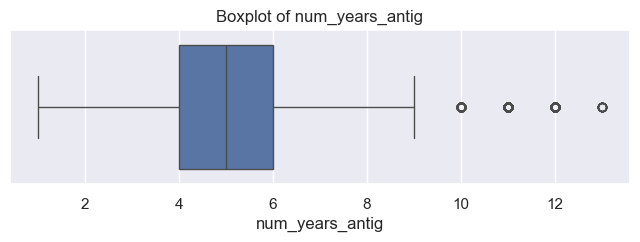

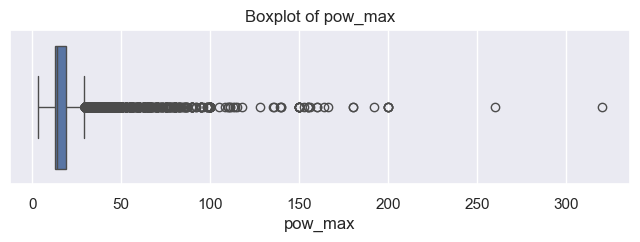

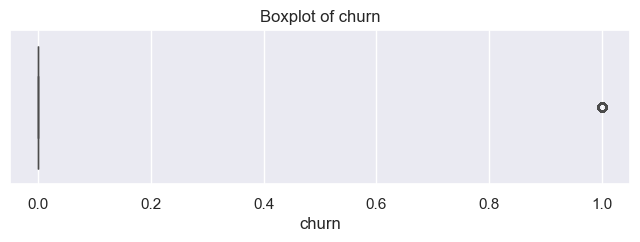

In [26]:
import numpy as np
numerical_cols = client_df.select_dtypes(include= np.number).columns

for col in numerical_cols:

    plt.figure(figsize=(8,2))
    sns.boxplot( x=client_df[col])

    plt.title(f"Boxplot of {col}")
    plt.show()

#### Observation
We can see some outliers here as well which we will deal with in the feature engineering

#### Correlation
Relationship Between Dependent and indepenedent Feature

In [27]:
client_df.corr(numeric_only=True)["churn"].sort_values(ascending=False)

churn                             1.000000
margin_net_pow_ele                0.095772
margin_gross_pow_ele              0.095725
forecast_meter_rent_12m           0.044245
net_margin                        0.041135
pow_max                           0.030362
forecast_price_energy_peak        0.029315
forecast_discount_energy          0.017026
forecast_price_pow_off_peak       0.014778
forecast_cons_12m                 0.012949
imp_cons                         -0.001583
forecast_cons_year               -0.002558
forecast_price_energy_off_peak   -0.010837
nb_prod_act                      -0.014930
cons_gas_12m                     -0.037957
cons_last_month                  -0.045284
cons_12m                         -0.045968
num_years_antig                  -0.074140
Name: churn, dtype: float64

Your focus should be on features that are highy positively or negatively correlated with the target variable, then filter with domain knowledge for analysis

**Question**: Do churned customers have lower margins?

In [28]:
client_df.groupby("churn")["net_margin"].mean()

churn
0    185.057407
1    228.361938
Name: net_margin, dtype: float64

Churned customers actually generate higher margins on average.

**Question** : Do churned customers have shorter tenure?

In [29]:
client_df.groupby("churn")["num_years_antig"].mean()

churn
0    5.037006
1    4.633545
Name: num_years_antig, dtype: float64

Churned customers tend to have shorter tenure.Customers are most vulnerable during their early years with the company.

**Question** : Did churned customers consumer more electricity for the past 12 months

In [30]:
client_df.groupby("churn")["cons_12m"].median()

churn
0    14075.0
1    14529.0
Name: cons_12m, dtype: float64

Retained customers spent more electricity for the past 12 onths. Made use of "median" because "cons_12m" column has outliers

#### Data Visualization

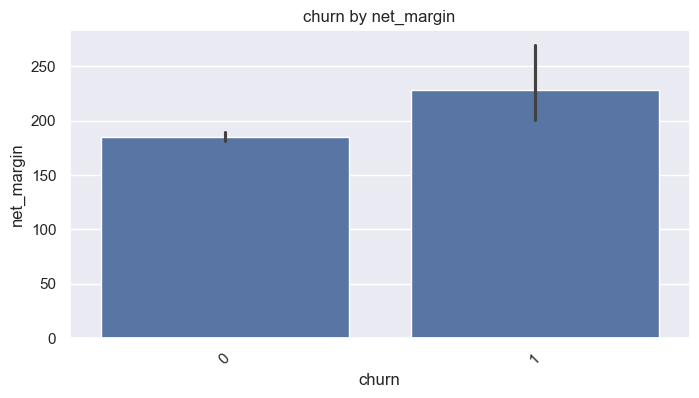

In [31]:
plt.figure(figsize=(8,4))
sns.barplot(data=client_df,x='churn', y='net_margin')

plt.title("churn by net_margin")
plt.xticks(rotation=45)
plt.show()

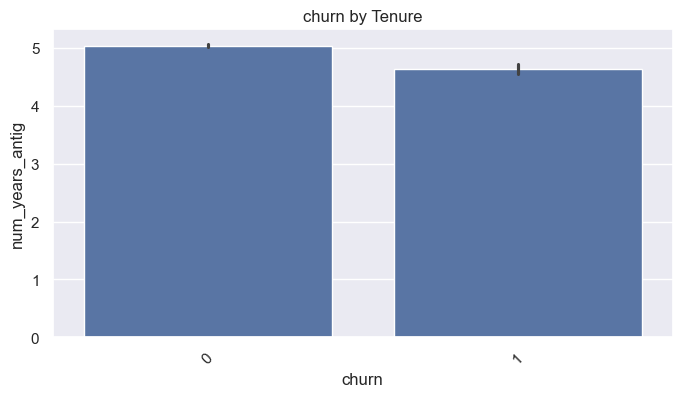

In [32]:
plt.figure(figsize=(8,4))
sns.barplot(data=client_df,x='churn', y='num_years_antig')

plt.title("churn by Tenure")
plt.xticks(rotation=45)
plt.show()

##### Categorical Variable Analysis
Churn by channel_sales

In [33]:
#"How many customers churned and how many stayed, broken down by sales channel?"
client_df.groupby(["churn","channel_sales"])["id"].count()

churn  channel_sales                   
0      MISSING                             3442
       epumfxlbckeskwekxbiuasklxalciiuu       3
       ewpakwlliwisiwduibdlfmalxowmwpci     818
       fixdbufsefwooaasfcxdxadsiekoceaa       2
       foosdfpfkusacimwkcsosbicdxkicaua    5934
       lmkebamcaaclubfxadlmueccxoimlema    1740
       sddiedcslfslkckwlfkdpoeeailfpeds      11
       usilxuppasemubllopkaafesmlibmsdf    1237
1      MISSING                              283
       ewpakwlliwisiwduibdlfmalxowmwpci      75
       foosdfpfkusacimwkcsosbicdxkicaua     820
       lmkebamcaaclubfxadlmueccxoimlema     103
       usilxuppasemubllopkaafesmlibmsdf     138
Name: id, dtype: int64

**Observation**
- 3442 customers acquired through "Unknown sales channel" stayed, while 283 customers acquired through the channel left
- 818 customers acquired through "ewpakwlliwisiwduibdlfmalxowmwpci sales channel" stayed, while 75 customers acquired through the channel left
- 5934 customers acquired through "foosdfpfkusacimwkcsosbicdxkicaua sales channel" stayed, while 820 customers acquired through the channel left
- 1740 customers acquired through "lmkebamcaaclubfxadlmueccxoimlema sales channel" stayed, while 103 customers acquired through the channel left
- 1237 customers acquired throug "usilxuppasemubllopkaafesmlibmsdf sales channel" stayed, while 138 customers acquired through the channel left

## Feature Engineering
Feature engineering refers to addition, deletion and  Combination of your dataset to improve machine learning model training, leading to better performance and greater accuracy.

In [34]:
# Importing the cleaned client dataset containing variance of price fluctaution for each customers
df = pd.read_csv(r"C:\working_files\cleaned_PowerCo_Data_after_eda.csv")

In [35]:
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14606 non-null  object        
 1   channel_sales                   14606 non-null  object        
 2   cons_12m                        14606 non-null  int64         
 3   cons_gas_12m                    14606 non-null  int64         
 4   cons_last_month                 14606 non-null  int64         
 5   date_activ                      14606 non-null  datetime64[ns]
 6   date_end                        14606 non-null  datetime64[ns]
 7   date_modif_prod                 14606 non-null  datetime64[ns]
 8   date_renewal                    14606 non-null  datetime64[ns]
 9   forecast_cons_12m               14606 non-null  float64       
 10  forecast_cons_year              14606 non-null  int64         
 11  fo

#### Price Dataset

In [37]:
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


#### Price Data Description 
- id = client company identifier
- price_date = reference date
- price_off_peak_var = price of energy for the 1st period (off peak)
- price_peak_var = price of energy for the 2nd period (peak)
- price_mid_peak_var = price of energy for the 3rd period (mid peak)
- price_off_peak_fix = price of power for the 1st period (off peak)
- price_peak_fix = price of power for the 2nd period (peak)
- price_mid_peak_fix = price of power for the 3rd period (mid peak)                      

**Note** : In general business context 1st period = 1st quarter(Q1), 2nd period = 2nd quarter(Q2), 3rd period = 3rd quarter(Q3) but in Electricity the three periods are simply time slots in the day when electricity is priced differently:
- Off-peak (night) ---> cheapest
- Mid-peak (daytime) ---> medium
- Peak (evening) -->  most expensive

In [38]:
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')

In [39]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  193002 non-null  object        
 1   price_date          193002 non-null  datetime64[ns]
 2   price_off_peak_var  193002 non-null  float64       
 3   price_peak_var      193002 non-null  float64       
 4   price_mid_peak_var  193002 non-null  float64       
 5   price_off_peak_fix  193002 non-null  float64       
 6   price_peak_fix      193002 non-null  float64       
 7   price_mid_peak_fix  193002 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 11.8+ MB


#### Measure how much each customer's off-peak energy and power prices changed from the beginning of 2015 (January) to the end of 2015 (December).

In [40]:
print(price_df["price_date"].min())
print(price_df["price_date"].max())

2015-01-01 00:00:00
2015-12-01 00:00:00


This confirms that the date we are working with is 2015

In [41]:
# January 2015 Price vs December 2015 Price
# =====================================================

# Sort the dataset by customer ID and date.This ensures January comes first and December comes last
price_df = price_df.sort_values(["id", "price_date"])

# Get each customer's first recorded price (January)
jan_price = (price_df.groupby("id").first().reset_index())

# Keep only the columns needed
jan_price = jan_price[["id", "price_off_peak_var", "price_off_peak_fix"]]

# Rename columns for clarity
jan_price.columns = ["id","jan_energy_price","jan_power_price"]

# Get each customer's last recorded price (December)
dec_price = ( price_df.groupby("id").last().reset_index())

# Keep only the columns needed
dec_price = dec_price[["id", "price_off_peak_var", "price_off_peak_fix"]]

# Rename columns for clarity
dec_price.columns = [ "id","dec_energy_price","dec_power_price"]

# Combine January and December prices
price_change = pd.merge( jan_price,dec_price,on="id")


In [42]:

# Calculate price changes during 2015
#--------------------------------------------------------------
# Change in off-peak energy price
price_change["offpeak_energy_price_dec_jan"] = (price_change["dec_energy_price"]- price_change["jan_energy_price"])

# Change in off-peak power price
price_change["offpeak_power_price_dec_jan"] = (price_change["dec_power_price"] - price_change["jan_power_price"])

# Keep only the engineered features
# -----------------------------------------------------
price_change = price_change[ [ "id","offpeak_energy_price_dec_jan", "offpeak_power_price_dec_jan"]]
price_change.head()

,id,offpeak_energy_price_dec_jan,offpeak_power_price_dec_jan
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


In [43]:
# Merging this information to the "clean_PowerCoData_after_eda" dataset containing the customers records
df = pd.merge(df, price_change, on='id')
df.head(2)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_year_price_peak_var,var_year_price_mid_peak_var,var_year_price_off_peak_fix,var_year_price_peak_fix,var_year_price_mid_peak_fix,var_year_price_off_peak,var_year_price_peak,var_year_price_mid_peak,offpeak_energy_price_dec_jan,offpeak_power_price_dec_jan
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000026,0.00044,1.102785,49.550703,22.022535,1.102846,49.550729,22.022975,0.020057,3.700961
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000609,0.00000,0.006465,0.000000,0.000000,0.006470,0.000609,0.000000,-0.003767,0.177779


## Average price changes across periods
We can now enhance the feature by calculating the average price changes across individual periods, instead of the entire year.
- Off-peak (night) ---> cheapest
- Mid-peak (daytime) ---> medium
- Peak (evening) -->  most expensive

In [44]:
# Aggregate average variable prices per company
Avg_prices = price_df.groupby('id').agg({
    'price_off_peak_var': 'mean',
    'price_peak_var': 'mean',
    'price_mid_peak_var': 'mean'
}).reset_index()

**Note** : This code groups by only id — no date.So the code is calculating the average for each customer across the entire year (all months combined).

In [45]:
# Calculate average price differences
Avg_prices['Avg_Offpeak_Peak_Var_Price_Diff'] = Avg_prices['price_off_peak_var'] - Avg_prices['price_peak_var']
Avg_prices['Avg_Peak_Mid_Peak_Var_Price_Diff'] = Avg_prices['price_peak_var'] - Avg_prices['price_mid_peak_var']
Avg_prices['Avg_Off_Peak_Mid_Peak_Var_Price_Diff'] = Avg_prices['price_off_peak_var'] - Avg_prices['price_mid_peak_var']

In [46]:
AvgPrice_change = Avg_prices[[
    'id','Avg_Offpeak_Peak_Var_Price_Diff',
    'Avg_Peak_Mid_Peak_Var_Price_Diff', 
    'Avg_Off_Peak_Mid_Peak_Var_Price_Diff'
]]


In [47]:
df = pd.merge(df, AvgPrice_change, on='id')

In [48]:
df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_year_price_peak_fix,var_year_price_mid_peak_fix,var_year_price_off_peak,var_year_price_peak,var_year_price_mid_peak,offpeak_energy_price_dec_jan,offpeak_power_price_dec_jan,Avg_Offpeak_Peak_Var_Price_Diff,Avg_Peak_Mid_Peak_Var_Price_Diff,Avg_Off_Peak_Mid_Peak_Var_Price_Diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,49.550703,22.022535,1.102846,4.955073e+01,22.022975,0.020057,3.700961,0.024038,0.034219,0.058257
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000000,0.000000,0.006470,6.089453e-04,0.000000,-0.003767,0.177779,0.142485,0.007124,0.149609
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000000,0.000000,0.007668,2.558511e-07,0.000000,-0.004670,0.177779,0.082090,0.088421,0.170512


 Instead of looking at differences across an entire year, we have now created features that look at mean average price differences across different time periods (off_peak, peak, mid_peak). The dec-jan feature may reveal macro patterns that occur over an entire year, whereas inter-time-period features may reveal patterns on a micro scale between months.

## Max price changes across periods and months
- Off-peak (night) ---> cheapest
- Mid-peak (daytime) ---> medium
- Peak (evening) -->  most expensive

In [49]:
price_df.columns

Index(['id', 'price_date', 'price_off_peak_var', 'price_peak_var',
       'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix',
       'price_mid_peak_fix'],
      dtype='object')

In [50]:
# Aggregate average prices per period by company
Avg_prices = price_df.groupby(['id','price_date']).agg({
    'price_off_peak_var': 'mean', 
    'price_peak_var': 'mean', 
    'price_mid_peak_var': 'mean',   
}).reset_index()

**Note** : The code above grouped by **id and price-date** .So the code is calculating the average price of the periods for each customers across all months.

In [51]:
# Calculate the mean difference between consecutive periods across all months
Avg_prices['Avg_Offpeak_Peak_Var_Price_Diff'] = Avg_prices['price_off_peak_var'] - Avg_prices['price_peak_var']
Avg_prices['Avg_Peak_Mid_Peak_Var_Price_Diff'] = Avg_prices['price_peak_var'] - Avg_prices['price_mid_peak_var']
Avg_prices['Avg_Off_Peak_Mid_Peak_Var_Price_Diff'] = Avg_prices['price_off_peak_var'] - Avg_prices['price_mid_peak_var']

**Note** The new columns created is not a one average summary number , it holds a different difference value for each periods across all months from Jan to Dec.Each new column stores all 12 monthly differences in one column

In [52]:
max_diff_across_periods_months = Avg_prices.groupby("id").agg({
   'Avg_Offpeak_Peak_Var_Price_Diff' : 'max',
   'Avg_Peak_Mid_Peak_Var_Price_Diff' : 'max',
   'Avg_Off_Peak_Mid_Peak_Var_Price_Diff' : 'max',
}).reset_index().rename(
    columns={
    'Avg_Offpeak_Peak_Var_Price_Diff' : 'Offpeak_peak_var_highest_monthly_price_diff',
    'Avg_Peak_Mid_Peak_Var_Price_Diff' : 'Peak_Mid_Peak_Var_highest_monthly_price_diff',
    'Avg_Off_Peak_Mid_Peak_Var_Price_Diff': 'Off_Peak_Mid_Peak_Var_highest_monthly_price_diff',
    })

In [53]:
Monthly_avg_price_diff =max_diff_across_periods_months[[
    'id',
    'Offpeak_peak_var_highest_monthly_price_diff',
    'Peak_Mid_Peak_Var_highest_monthly_price_diff',
    'Off_Peak_Mid_Peak_Var_highest_monthly_price_diff',
]]  

In [54]:
df = pd.merge(df,Monthly_avg_price_diff, on ='id')

In [55]:
df.head(1)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_year_price_peak,var_year_price_mid_peak,offpeak_energy_price_dec_jan,offpeak_power_price_dec_jan,Avg_Offpeak_Peak_Var_Price_Diff,Avg_Peak_Mid_Peak_Var_Price_Diff,Avg_Off_Peak_Mid_Peak_Var_Price_Diff,Offpeak_peak_var_highest_monthly_price_diff,Peak_Mid_Peak_Var_highest_monthly_price_diff,Off_Peak_Mid_Peak_Var_highest_monthly_price_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,49.550729,22.022975,0.020057,3.700961,0.024038,0.034219,0.058257,0.06055,0.085483,0.146033


### Tenure
How long a company has been a client of PowerCo.

In [56]:
# The dt.days attribute allows you to extracts the duration that was substracted as an integer number of days.
# (.dt.days// 365) converts te numbers of days tyears by diving it by 365days

df['tenure'] = ((df['date_end'] - df['date_activ']).dt.days// 365)

In [57]:
df.groupby(['tenure']).agg({'churn': 'mean'}).sort_values(by='tenure', ascending=False)

,churn
tenure,
13,0.095238
12,0.083333
11,0.059783
10,0.045455
9,0.012500
8,0.047244
7,0.075472
6,0.075407
5,0.091999


We can see that companies who have only been a client for 4yrs or less years are much more likely to churn compared to companies that have been a client for longer years

- **month_to_end** : How close to contract end
- **months_renewal** : How recently they renewed  contract

In [58]:
# Create reference date
from datetime import datetime
reference_date = datetime(2016, 1, 1)
# Calculate months to contract end
end_year_diff = df['date_end'].dt.year - reference_date.year
end_month_diff = df['date_end'].dt.month - reference_date.month

# convert the years diff to months by multiplying by 12, then add to the remaining ned_months_diff
df['months_to_end'] = end_year_diff * 12 + end_month_diff

# Calculate months since renewal
renewal_year_diff = reference_date.year - df['date_renewal'].dt.year
renewal_month_diff = reference_date.month - df['date_renewal'].dt.month

df['months_renewal'] = renewal_year_diff * 12 + renewal_month_diff

In [59]:
# We no longer need the datetime columns that we used for feature engineering, so we can drop them

df.drop(columns=['id','date_activ', 'date_end','date_modif_prod','date_renewal'], inplace =True)
df.head()

,channel_sales,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,offpeak_power_price_dec_jan,Avg_Offpeak_Peak_Var_Price_Diff,Avg_Peak_Mid_Peak_Var_Price_Diff,Avg_Off_Peak_Mid_Peak_Var_Price_Diff,Offpeak_peak_var_highest_monthly_price_diff,Peak_Mid_Peak_Var_highest_monthly_price_diff,Off_Peak_Mid_Peak_Var_highest_monthly_price_diff,tenure,months_to_end,months_renewal
0,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,0.00,0,0.0,1.78,0.114481,0.098142,...,3.700961,0.024038,0.034219,0.058257,0.060550,0.085483,0.146033,3,5,7
1,MISSING,4660,0,0,189.95,0,0.0,16.27,0.145711,0.000000,...,0.177779,0.142485,0.007124,0.149609,0.151367,0.085483,0.151367,7,7,5
2,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,47.96,0,0.0,38.72,0.165794,0.087899,...,0.177779,0.082090,0.088421,0.170512,0.084587,0.089162,0.172468,6,3,9
3,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,240.04,0,0.0,19.83,0.146694,0.000000,...,0.177779,0.151210,0.000000,0.151210,0.153133,0.000000,0.153133,6,2,10
4,MISSING,4425,0,526,445.75,526,0.0,131.73,0.116900,0.100015,...,0.162916,0.020536,0.030773,0.051309,0.022225,0.033743,0.055866,6,2,10


## Transforming numerical data
The reason why we need to treat skewness is because some predictive models have inherent assumptions about the distribution of the features. Such models are called `parametric` models, and they typically assume that all variables are both independent and normally distributed.

Skewness isn't always a bad thing, but as a rule of thumb it is good practice to treat highly skewed variables to make them more normally distributed. This can also increase the speed at which predictive models are able to converge to the best solution.

There are many ways that you can treat skewed variables. You can apply transformations such as:
- Square root
- Cubic root
- Logarithm
- Box-cox

to a continuous numeric column and you will notice the distribution changes. For this use case we will use the 'Logarithm' transformation for the positively skewed features. 

-**Note** We cannot apply log to a value of 0, so we will add a constant of 1 to all the values

We will check the distributions before and after transformation, and expect the standard deviations to decrease.

In [60]:
skewed_columns = [
    'cons_12m', 
    'cons_gas_12m', 
    'cons_last_month',
    'forecast_cons_12m', 
    'forecast_cons_year', 
    'forecast_discount_energy',
    'forecast_meter_rent_12m', 
    'forecast_price_energy_off_peak',
    'forecast_price_energy_peak', 
    'forecast_price_pow_off_peak'
]

In [61]:
print("\nBefore log transform:")
print(df[skewed_columns].describe())

df[skewed_columns] = np.log10(df[skewed_columns] + 1)

print("After log transform:")
print(df[skewed_columns].describe())


Before log transform:
           cons_12m  cons_gas_12m  cons_last_month  forecast_cons_12m  \
count  1.460600e+04  1.460600e+04     14606.000000       14606.000000   
mean   1.592203e+05  2.809238e+04     16090.269752        1868.614880   
std    5.734653e+05  1.629731e+05     64364.196422        2387.571531   
min    0.000000e+00  0.000000e+00         0.000000           0.000000   
25%    5.674750e+03  0.000000e+00         0.000000         494.995000   
50%    1.411550e+04  0.000000e+00       792.500000        1112.875000   
75%    4.076375e+04  0.000000e+00      3383.000000        2401.790000   
max    6.207104e+06  4.154590e+06    771203.000000       82902.830000   

       forecast_cons_year  forecast_discount_energy  forecast_meter_rent_12m  \
count        14606.000000              14606.000000             14606.000000   
mean          1399.762906                  0.966726                63.086871   
std           3247.786255                  5.108289                66.165783   

Now we can see that for the majority of the features, the standard deviation is much lower after transformation. This is a good thing as it shows that these features are more stable and predictable now.

### Declare Feature Vector and Target Variable

In [62]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [63]:
# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['churn','origin_up'])
print(X.shape)
print(y.shape)

(14606, 39)
(14606,)


#### Encoding using Lambda

In [64]:
df.has_gas.value_counts()

has_gas
f    11955
t     2651
Name: count, dtype: int64

In [65]:
X["has_gas"] = X["has_gas"].apply(lambda x:1 if x == "t" else 0 )

In [66]:
X["has_gas"].dtypes 

dtype('int64')

#### Encoding using Mapping

In [67]:
X.channel_sales.value_counts()

channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

In [68]:
X["channel_sales"] = X["channel_sales"].replace({'MISSING' : 'Unknown'})

In [69]:
X.channel_sales.value_counts()

channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
Unknown                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

In [70]:
X["channel_sales"] = X["channel_sales"] .map({'foosdfpfkusacimwkcsosbicdxkicaua':1,'lmkebamcaaclubfxadlmueccxoimlema':2,'usilxuppasemubllopkaafesmlibmsdf':3,'ewpakwlliwisiwduibdlfmalxowmwpci':4,'sddiedcslfslkckwlfkdpoeeailfpeds':5,'epumfxlbckeskwekxbiuasklxalciiuu':6, 'fixdbufsefwooaasfcxdxadsiekoceaa':7, 'Unknown' :8 })

In [71]:
X.channel_sales.value_counts()

channel_sales
1    6754
8    3725
2    1843
3    1375
4     893
5      11
6       3
7       2
Name: count, dtype: int64

#### Split Data Into Seperate Training and Test Set

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10224, 39)
(10224,)
(4382, 39)
(4382,)


### Model training
Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms.For this example, I am using `n_estimators` = 1000. This means that my random forest will consist of 1000 decision trees.

In [73]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=1000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1

In [74]:
# Prediction on test set
y_pred = model.predict(X_test)

### Model Evaluation
It helps to evaluate how well this trained model is able to predict the values of the test dataset.
We are going to use 3 metrics to evaluate performance:

- Accuracy = the ratio of correctly predicted observations to the total observations
- Precision = the ability of the classifier to not label a negative sample as positive
- Recall = the ability of the classifier to find all the positive samples
The reason why we are using these three metrics is because a simple accuracy is not always a good measure to use.

In [75]:
from sklearn.metrics import accuracy_score
from sklearn import metrics
acc_rf = round(metrics.accuracy_score(y_test,y_pred)*100,2)
print('Model accuracy score for Randomm Forest:',acc_rf)

Model accuracy score for Randomm Forest: 89.94


In [76]:
from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred,
    labels=[0,1],
    target_names=['No','Yes']
))

              precision    recall  f1-score   support

          No       0.91      0.98      0.95      3942
         Yes       0.50      0.15      0.23       440

    accuracy                           0.90      4382
   macro avg       0.70      0.57      0.59      4382
weighted avg       0.87      0.90      0.87      4382



#### Model Understanding

In [77]:
feature_importances = pd.DataFrame({
    'features': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=True).reset_index()


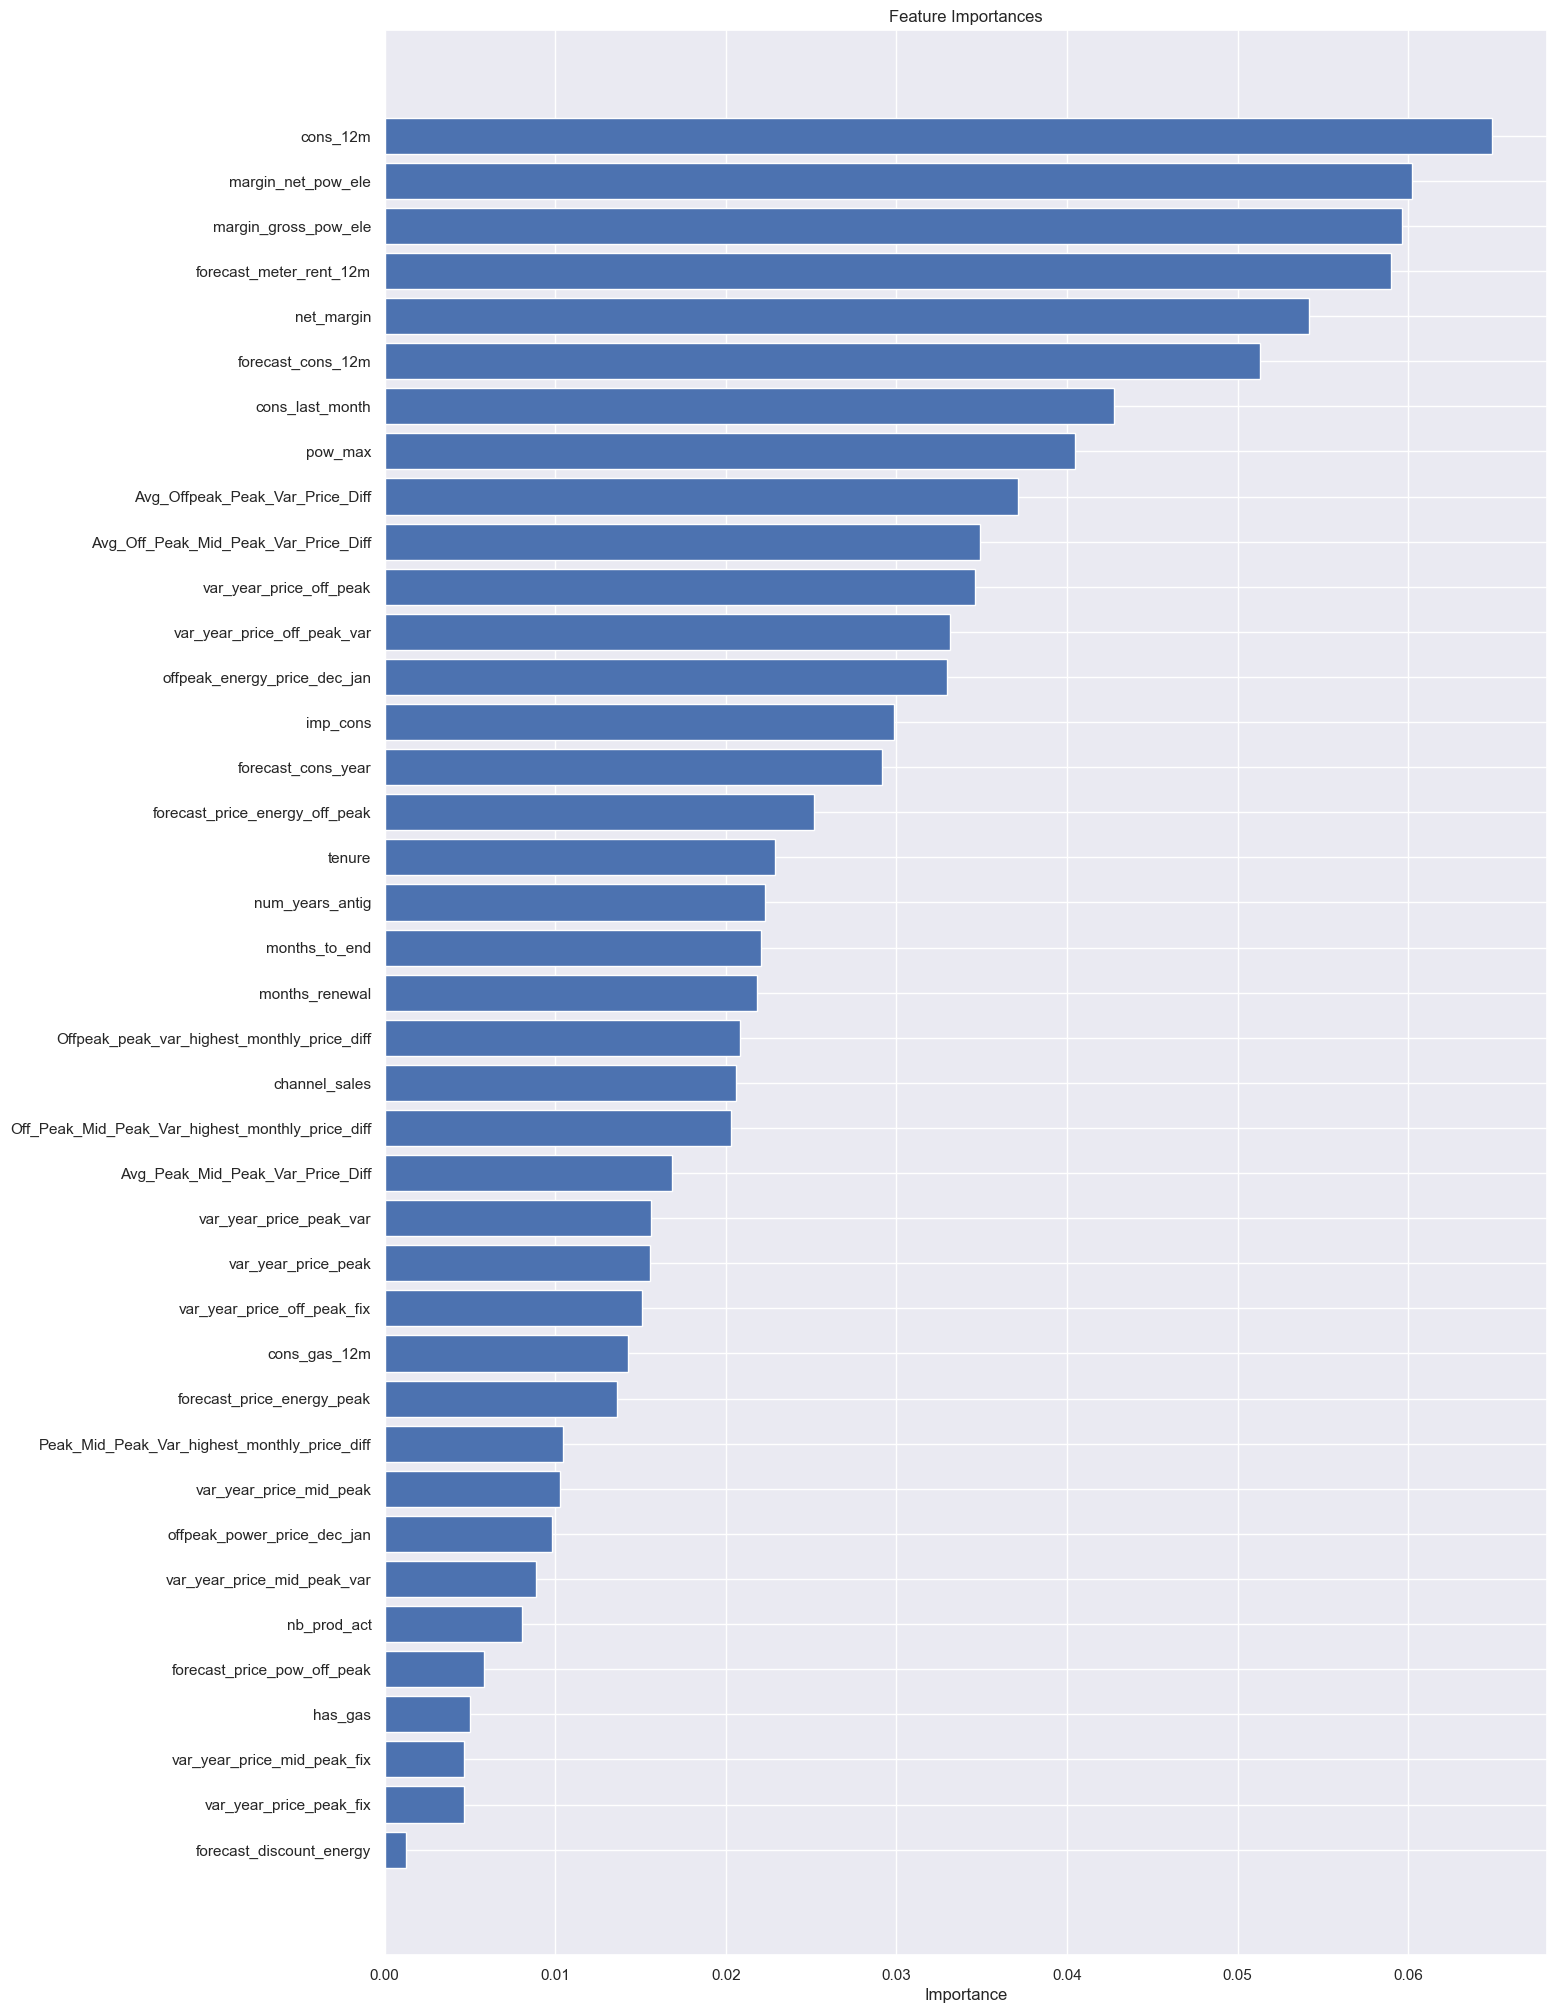

In [78]:
plt.figure(figsize=(15, 25))
plt.title('Feature Importances')
plt.barh(range(len(feature_importances)), feature_importances['importance'], color='b', align='center')
plt.yticks(range(len(feature_importances)), feature_importances['features'])
plt.xlabel('Importance')
plt.show()

#### Observation
- Net margin and consumption over 12 months is a top driver for churn in this model
- Margin on power subscription also is an influential driver
- Time seems to be an influential factor, especially the number of months_to_end, month renewal and their tenure 
- Our price sensitivity features are scattered around but are not the main driver for a customer churning

The last observation is important because this relates back to our **original hypothesis**:

**Is churn driven by the customers' price sensitivity?**

**Answer** Based on the output of the feature importances, it is not a main driver but it is a weak contributor. 